# Workshop: Comparing Trump’s Twitter and Truth Social Communication

In this workshop we compare Donald Trump’s social media messages from:

- the **first period of his first presidency**: 20 January 2017–11 May 2018
- the **first period of his second presidency**: 20 January 2025–11 May 2026


## Example question:

> Did Trump’s social media communication become more **grievance-oriented, enemy-focused, and institutionally hostile** in the first year of his second presidency compared to the first year of his first presidency?

Later, each group will choose its own question and repeat the same workflow.

In [ ]:
!pip3 install pandas
!pip3 install numpy 


In [1]:
# Core packages
import pandas as pd
import numpy as np
import re
from pathlib import Path

# Plotting
import matplotlib.pyplot as plt

# Text analysis

pd.set_option("display.max_colwidth", 200)

In [2]:
# We read the messages
df1 = pd.read_csv('trump_first.csv')
df2 = pd.read_csv('trump_second.csv')

## 1. Inspect the data

Before analyzing text, always inspect the dataset. We want to know:

- how many rows we have;
- what the time range is;
- which platforms are included;
- whether the text column contains missing values;
- whether reshared or deleted posts should be included.

In [3]:
print("Rows first presidency:", len(df1))
print("Rows second presidency:", len(df2))
print("Columns:", list(df1.columns))
print("Columns:", list(df2.columns))

display(df1.head(3))
display(df2.head(3))

Rows first presidency: 3342
Rows second presidency: 6164
Columns: ['id', 'text', 'isRetweet', 'isDeleted', 'device', 'favorites', 'retweets', 'date', 'isFlagged', 'period']
Columns: ['id', 'date', 'text', 'url', 'favorites', 'retweets', 'replies', 'period']


,id,text,isRetweet,isDeleted,device,favorites,retweets,date,isFlagged,period
0,938422792080457731,MAKE AMERICA GREAT AGAIN!,f,f,Twitter for iPhone,157963,37189,2017-12-06 15:00:03+00:00,f,1
1,939189419386470401,MAKE AMERICA GREAT AGAIN! https://t.co/64a93S07s7,f,f,Twitter for iPhone,56596,11433,2017-12-08 17:46:21+00:00,f,1
2,935340092583006208,Thank you Rand! https://t.co/NvPeleVmub,f,f,Twitter for iPhone,42793,9125,2017-11-28 02:50:30+00:00,f,1


,id,date,text,url,favorites,retweets,replies,period
0,116558534552033932,2026-05-11 23:28:12.201000+00:00,"As I said at my State of the Union Address on February 25th, the American Dream of Homeownership is under attack. For example, Rachel Wiggins, a mom of two, from Houston, placed bids on 20 homes, ...",https://truthsocial.com/@realDonaldTrump/116558534552033932,13442,3860,1380,2
1,116558478762586433,2026-05-11 23:14:00.920000+00:00,"The South Carolina State Senate has a big vote tomorrow on Redistricting. I’m watching closely, along with all Republicans across the Country who are counting on their Elected Leaders to use every...",https://truthsocial.com/@realDonaldTrump/116558478762586433,10364,2932,516,2
2,116558198309722328,2026-05-11 22:02:41.548000+00:00,It is my Great Honor to nominate Michael Martin to serve as Judge on the U.S. District Court for the Eastern District of Michigan! Mike has served as a Federal Prosecutor for more than two decades...,https://truthsocial.com/@realDonaldTrump/116558198309722328,8788,2000,458,2


In [6]:
# Convert date to datetime
# errors="coerce" turns invalid dates into NaT rather than crashing.
df1["date"] = pd.to_datetime(df1["date"], errors="coerce", utc=True)
df2["date"] = pd.to_datetime(df2["date"], errors="coerce", utc=True)

print("Date range:")
print(df1["date"].min(), "to", df1["date"].max())
print(df2["date"].min(), "to", df2["date"].max())


Date range:
2017-01-20 00:40:51+00:00 to 2018-05-11 23:49:40+00:00
2025-01-21 05:28:49.169000+00:00 to 2026-05-11 23:28:12.201000+00:00


In [7]:
# We combine the two periods to one dataframe
df1['period'] = 1
df2['period'] = 2

df = pd.concat([df1,df2])


## 2. Clean the text lightly

We do not want to over-clean. Social media punctuation, capitalization, hashtags, and exclamation marks may be substantively meaningful.

For most methods below, we create:

- `text_raw`: original text as string;
- `text_clean`: lowercased text with URLs removed and whitespace normalized.

In [8]:
def clean_text(s):
    s = "" if pd.isna(s) else str(s)
    s = re.sub(r"https?://\S+|www\.\S+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

analysis_df = df.copy()
analysis_df["text_raw"] = analysis_df["text"].fillna("").astype(str)
analysis_df["text_clean"] = analysis_df["text_raw"].apply(clean_text)
analysis_df["text_lower"] = analysis_df["text_clean"].str.lower()

# Basic text features
analysis_df["n_chars"] = analysis_df["text_clean"].str.len()
analysis_df["n_words"] = analysis_df["text_clean"].str.split().str.len()
analysis_df["n_exclaim"] = analysis_df["text_raw"].str.count("!")
analysis_df["n_question"] = analysis_df["text_raw"].str.count(r"\?")
analysis_df["share_caps"] = analysis_df["text_raw"].apply(
    lambda x: sum(1 for c in str(x) if c.isupper()) / max(1, sum(1 for c in str(x) if c.isalpha()))
)

analysis_df[["date", "text_clean", "n_words", "period", "n_exclaim", "share_caps"]].head()

,date,text_clean,n_words,period,n_exclaim,share_caps
0,2017-12-06 15:00:03+00:00,MAKE AMERICA GREAT AGAIN!,4,1,1,1.000000
1,2017-12-08 17:46:21+00:00,MAKE AMERICA GREAT AGAIN!,4,1,1,0.687500
2,2017-11-28 02:50:30+00:00,Thank you Rand!,3,1,1,0.166667
3,2017-10-31 15:48:22+00:00,Thank you @LuisRiveraMarin!,3,1,1,0.205128
4,2017-08-22 01:00:10+00:00,"Join me live from Fort Myer in Arlington, Virginia. ➡️",10,1,0,0.189655


## 3. Method 1: simple descriptive comparison

Before using fancy methods, look at simple differences.

Questions:

- Did he post more often?
- Were posts longer or shorter?
- Was punctuation more intense?
- Did capitalization change?
- Did engagement differ?

These are not direct measures of “grievance politics,” but they help us understand the communication environment.

In [9]:
summary = analysis_df.groupby("period").agg(
    n_posts=("id", "count"),
    mean_words=("n_words", "mean"),
    median_words=("n_words", "median"),
    mean_exclaim=("n_exclaim", "mean"),
    mean_question=("n_question", "mean"),
    mean_share_caps=("share_caps", "mean"),
).round(3)

summary

,n_posts,mean_words,median_words,mean_exclaim,mean_question,mean_share_caps
period,,,,,,
1,3342,23.706,23.0,0.639,0.064,0.124
2,6164,50.894,20.0,1.152,0.107,0.153


### Discussion

What can these variables tell us? What can they not tell us?

For example, an increase in exclamation marks may suggest a more performative or emotional style, but it does not tell us whether the content is grievance-oriented.

## 4. Operationalize the main concept

Our example concept is **grievance politics**.

For this workshop, we define it as communication that does one or more of the following:

1. presents Trump or his supporters as unfairly treated;
2. identifies hostile enemies or outgroups;
3. attacks or delegitimizes institutions;
4. calls supporters to mobilize against those enemies or institutions.

This is only one possible definition. Other groups may define a different concept.

## 5. Method 2: keyword dictionaries

A dictionary is a list of words or phrases that we treat as indicators of a concept.

Strengths:

- transparent;
- easy to understand;
- fast;
- reproducible.

Weaknesses:

- misses synonyms and indirect references;
- may confuse different meanings of the same word;
- depends heavily on the researcher’s choices;
- often captures rhetoric rather than meaning.

In [10]:
# These dictionaries are intentionally simple.
# You can inspect, criticize, and improve them!

dictionaries = {
    "grievance": [
        "witch hunt", "hoax", "rigged", "stolen", "scam", "persecution",
        "unfair", "treated unfairly", "weaponized", "corrupt", "fake case",
        "political prosecution", "election interference", "they are after me",
        "never seen anything like it"
    ],
    "enemy": [
        "fake news", "radical left", "democrats", "deep state", "media",
        "rinos", "biden", "crooked", "corrupt", "prosecutors", "fbi",
        "department of justice", "doj", "communists", "marxists", "globalists"
    ],
    "institutional_attack": [
        "fake news", "rigged election", "stolen election", "corrupt judge",
        "corrupt court", "weaponized justice", "department of justice", "doj",
        "fbi", "prosecutor", "prosecutors", "indictment", "election interference",
        "mainstream media", "lamestream media"
    ],
    "mobilization": [
        "vote", "donate", "join", "sign", "watch", "share", "support",
        "rally", "turn out", "make america great again", "maga", "save america"
    ],
    "policy": [
        "tax", "border", "immigration", "jobs", "inflation", "trade", "china",
        "healthcare", "crime", "police", "energy", "oil", "tariffs", "education"
    ]
}

def contains_any(text, phrases):
    text = "" if pd.isna(text) else str(text).lower()
    return int(any(phrase.lower() in text for phrase in phrases))

for name, phrases in dictionaries.items():
    analysis_df[f"dict_{name}"] = analysis_df["text_lower"].apply(lambda x: contains_any(x, phrases))

analysis_df[["period", "text_clean"] + [f"dict_{k}" for k in dictionaries]].head()

,period,text_clean,dict_grievance,dict_enemy,dict_institutional_attack,dict_mobilization,dict_policy
0,1,MAKE AMERICA GREAT AGAIN!,0,0,0,1,0
1,1,MAKE AMERICA GREAT AGAIN!,0,0,0,1,0
2,1,Thank you Rand!,0,0,0,0,0
3,1,Thank you @LuisRiveraMarin!,0,0,0,0,0
4,1,"Join me live from Fort Myer in Arlington, Virginia. ➡️",0,0,0,1,0


In [11]:
dict_cols = [f"dict_{k}" for k in dictionaries]

dict_summary = analysis_df.groupby("period")[dict_cols].mean().T.round(3)
dict_summary

period,1,2
dict_grievance,0.032,0.049
dict_enemy,0.159,0.164
dict_institutional_attack,0.082,0.049
dict_mobilization,0.157,0.206
dict_policy,0.207,0.240


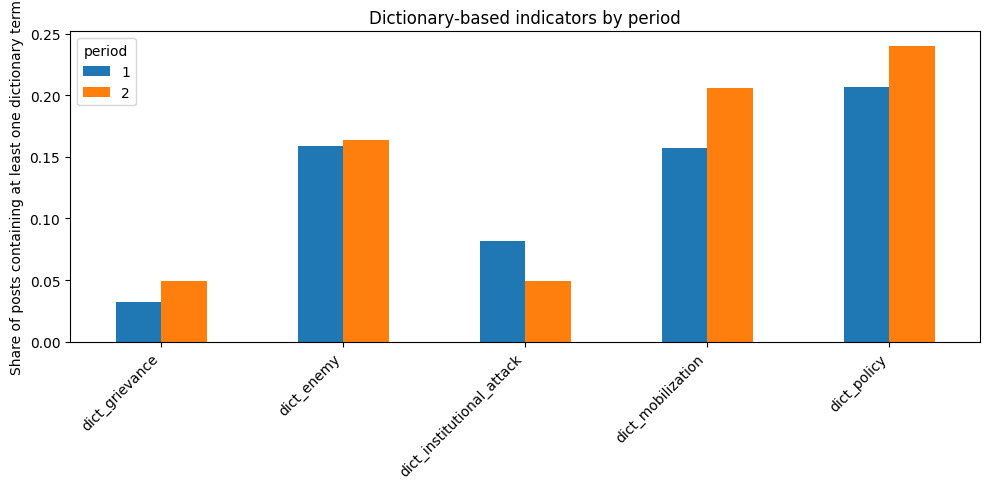

In [12]:
dict_summary.plot(kind="bar", figsize=(10, 5))
plt.title("Dictionary-based indicators by period")
plt.ylabel("Share of posts containing at least one dictionary term")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Inspect examples

Never trust aggregate results before inspecting texts.

The next cell shows examples that were flagged by each dictionary. Look for false positives and false negatives.

In [13]:
def show_examples(flag_col, period=None, n=5, random_state=42):
    tmp = analysis_df[analysis_df[flag_col] == 1]
    if period is not None:
        tmp = tmp[tmp["period"] == period]
    if len(tmp) == 0:
        print("No examples found.")
        return pd.DataFrame()
    return tmp.sample(min(n, len(tmp)), random_state=random_state)[["period", "date", "text_clean"]]

show_examples("dict_grievance", n=10)

,period,date,text_clean
2619,1,2018-04-28 01:19:53+00:00,"House Intelligence Committee rules that there was NO COLLUSION between the Trump Campaign and Russia. As I have been saying all along, it is all a big Hoax by the Democrats based on payments and l..."
2051,2,2025-12-03 15:29:13.389000+00:00,"RT: years, the Biden Administration weaponized the Justice System against their Political Opponents, and anyone who disagreed with them. One of the clearest examples of this was when Crooked Joe u..."
2801,2,2025-10-12 15:04:26.557000+00:00,"The Ukraine Impeachment (of me!) Scam was a far bigger Illegal Hoax than Watergate. I sincerely hope the necessary authorities, including CONGRESS, are looking into this! Adam “Schiffty” Schiff wa..."
1418,1,2017-07-29 11:07:18+00:00,"In other words, Russia was against Trump in the 2016 Election - and why not, I want strong military &amp, low oil prices. Witch Hunt!"
1714,1,2017-06-22 14:08:50+00:00,"...Why did the DNC REFUSE to turn over its Server to the FBI, and still hasn't? It's all a big Dem scam and excuse for losing the election!"
2719,1,2018-04-17 22:59:20+00:00,States and Cities throughout our Country are being cheated and treated so badly by online retailers. Very unfair to traditional tax paying stores!
545,2,2026-03-31 19:28:49.254000+00:00,"The National Trust for Historic Preservation sues me for a Ballroom that is under budget, ahead of schedule, being built at no cost to the Taxpayer, and will be the finest Building of its kind any..."
4112,2,2025-06-28 02:42:24.107000+00:00,Who in the Fake News Media is the SleazeBag saying that “President Trump wants to give Iran $30 Billion to build non-military Nuclear facilities.” Never heard of this ridiculous idea. It’s just an...
2508,2,2025-11-03 19:30:04.491000+00:00,"Congressman Mark Alford is an America First Patriot, who is doing a fantastic job representing Missouri’s 4th Congressional District! Mark worked for 35 years as a local News Anchor, and his cover..."
2939,2,2025-09-26 21:38:31.404000+00:00,"Corrupt and Totally Trump Deranged Lisa Monaco (A purported pawn of Legal Lightweight Andrew Weissmann), was a senior National Security aide under Barack Hussein Obama, and a Lawfare and Weaponiza..."


Does it seem to work? Can you improve the keywords?

## 7. Method 3: distinctive words and phrases

Instead of starting with a theory-driven dictionary, we can ask:

> Which words or phrases are most distinctive of each period?

This is useful for exploration. It should not be confused with measurement. A distinctive phrase may be substantively important, or it may simply reflect a specific event.

In [14]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
# You  may need to install scikit learn for this to work


In [ ]:
!pip install scikit-learn

In [15]:


# Use TF-IDF to identify distinctive terms.
# We use unigrams and bigrams, remove common English stopwords, and ignore very rare terms.

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.8
)

X = vectorizer.fit_transform(analysis_df["text_clean"].fillna(""))
terms = np.array(vectorizer.get_feature_names_out())

# Mean TF-IDF score by period
periods = analysis_df["period"].values
mean_scores = {}
for p in sorted(analysis_df["period"].unique()):
    mean_scores[p] = np.asarray(X[periods == p].mean(axis=0)).ravel()

tfidf_df = pd.DataFrame(mean_scores, index=terms)

def top_terms_for_period(period, n=25):
    other_periods = [p for p in tfidf_df.columns if p != period]
    score = tfidf_df[period] - tfidf_df[other_periods].mean(axis=1)
    return score.sort_values(ascending=False).head(n).to_frame("distinctiveness_score")

top_terms_for_period(1, 20)

,distinctiveness_score
amp,0.028264
foxandfriends,0.010392
realdonaldtrump,0.009499
news,0.008927
today,0.008651
tax,0.008408
fake,0.008307
fake news,0.007751
whitehouse,0.007722
jobs,0.007397


In [16]:
top_terms_for_period(2, 20)

,distinctiveness_score
rt,0.067156
trump,0.011793
president,0.010825
djt,0.010630
president djt,0.009173
secure,0.008044
donald,0.007341
donald trump,0.007303
states,0.006794
united states,0.006675


### Discussion

Ask:

- Are the distinctive phrases about issues, events, enemies, emotions, institutions, or mobilization?
- Do they support the dictionary results?
- Do they suggest new dictionary terms?
- Are we seeing a period effect, a platform effect, or an event effect?

## Method 4: LLM coding

Now we use an LLM as a coder.

Important: the LLM is not a magic truth machine. It is another measurement instrument. We still need:

- a clear codebook;
- examples;
- structured output;
- validation against human coding;
- reflection on errors.

### LLM coding task

We will code four variables:

1. `grievance`: presents Trump or his supporters as unfairly treated;
2. `enemy`: identifies a hostile group, person, or institution;
3. `institutional_attack`: attacks or delegitimizes institutions such as courts, elections, media, prosecutors, Congress, agencies, or universities;
4. `mobilization`: asks supporters to act, vote, donate, watch, share, protest, or otherwise support a cause.

Each variable is coded 0/1.

## LLM Coding Exercise: Using a Chatbot as a Text Classifier

In this step, we will use a chatbot such as ChatGPT, Claude, Gemini, or another model to code a small random sample of Trump’s Truth Social posts.

The goal is not to assume that the chatbot is automatically correct. Instead, we want to see how an LLM applies a coding scheme, where it agrees or disagrees with our own interpretation, and what kinds of posts are difficult to classify.

Run the code below to create a random sample of posts and generate a prompt. Copy the full prompt that is printed, paste it into your chatbot of choice, and ask the chatbot to return the coding table.

Afterwards, compare the chatbot’s classifications with your own reading of the posts. Pay special attention to ambiguous cases and to whether the chatbot is consistent in how it applies the categories.

In [17]:
import pandas as pd

# Create a random sample for manual chatbot coding
sample_size = 20

sample_for_chatbot = (
    analysis_df
    .dropna(subset=["text"])
    .sample(n=sample_size, random_state=42)
    .copy()
)

# Keep only useful columns
sample_for_chatbot = sample_for_chatbot[["id", "date", "text"]]

# Create a numbered text block that students can paste into ChatGPT/Claude/etc.
posts_text = "\n\n".join(
    [
        f"POST {i+1}\nID: {row.id}\nDATE: {row.date}\nTEXT: {row.text}"
        for i, row in enumerate(sample_for_chatbot.itertuples(index=False))
    ]
)

instructions = f"""
You are a careful text analyst. 

We are studying Donald Trump's Truth Social posts from the first year of his second presidency.

Please code each post using the following variables:

1. grievance
Code 1 if the post presents Trump, his supporters, or the country as unfairly treated, attacked, cheated, persecuted, silenced, or betrayed.
Code 0 otherwise.

2. enemy_construction
Code 1 if the post identifies a hostile person, group, institution, or outgroup.
Examples include Democrats, the media, courts, prosecutors, judges, immigrants, foreign enemies, RINOs, the deep state, or other named opponents.
Code 0 otherwise.

3. institutional_attack
Code 1 if the post attacks, delegitimizes, or undermines trust in institutions.
Examples include elections, courts, prosecutors, law enforcement, Congress, government agencies, the media, universities, or international institutions.
Code 0 otherwise.

4. mobilization
Code 1 if the post asks supporters to act, such as vote, donate, watch, attend, share, buy, boycott, call, sign, or support a campaign.
Code 0 otherwise.

For each post, return a table with these columns:

post_number
id
grievance
enemy_construction
institutional_attack
mobilization
brief_reason

Rules:
- Use only 0 or 1 for the four coding variables.
- The brief_reason should be no more than 15 words.
- If uncertain, choose the most reasonable code based on the text.
- Do not skip any posts.

Here are the posts:

{posts_text}
"""

print(instructions)


You are a careful text analyst. 

We are studying Donald Trump's Truth Social posts from the first year of his second presidency.

Please code each post using the following variables:

1. grievance
Code 1 if the post presents Trump, his supporters, or the country as unfairly treated, attacked, cheated, persecuted, silenced, or betrayed.
Code 0 otherwise.

2. enemy_construction
Code 1 if the post identifies a hostile person, group, institution, or outgroup.
Examples include Democrats, the media, courts, prosecutors, judges, immigrants, foreign enemies, RINOs, the deep state, or other named opponents.
Code 0 otherwise.

3. institutional_attack
Code 1 if the post attacks, delegitimizes, or undermines trust in institutions.
Examples include elections, courts, prosecutors, law enforcement, Congress, government agencies, the media, universities, or international institutions.
Code 0 otherwise.

4. mobilization
Code 1 if the post asks supporters to act, such as vote, donate, watch, attend, s


## Installing Ollama

Ollama lets you run small language models locally on your own computer.

### 1. Install Ollama

Go to the Ollama website and install it for your operating system:

```text
https://ollama.com/download
```

After installing, open a terminal and check that it works:

```bash
ollama --version
```

### 2. Download a small model

For this workshop, use a small model so that it runs on most laptops:

```bash
ollama pull llama3.2:1b
```

Alternative, even smaller:

```bash
ollama pull qwen2.5:0.5b
```

The download may take a few minutes.

### 3. Test the model

In the terminal, run:

```bash
ollama run llama3.2:1b
```

Then type something like:

```text
Classify this text as positive, negative, or neutral: I am very angry about the corrupt media.
```

Exit with:

```text
/bye
```

### 4. Install the Python package

In your notebook, run:

```python
!pip install ollama
```

### 5. Troubleshooting

If Python cannot connect to Ollama, make sure the Ollama app is running.

On Mac, open Ollama from Applications.

On Windows, start Ollama from the Start Menu.

On Linux, run:

```bash
ollama serve
```

For the workshop, students who cannot install Ollama can still participate by using the dictionary-based and manual coding parts.


### Local Ollama, if installed



Suggested small models:

```bash
ollama pull llama3.2:1b
# or
ollama pull qwen2.5:0.5b
```

Small local models are not always accurate. That is fine for teaching, because students can compare their errors to dictionary and human coding.

In [18]:
import ollama

response = ollama.chat(
    model="qwen2.5:0.5b",
    messages=[
        {"role": "user", "content": "Say hello in one sentence."}
    ]
)

print(response["message"]["content"])

Hello! I'm Qwen, an artificial intelligence developed by Alibaba Cloud. How may I assist you today?


## Let's use it to analyse whether there is more grievance in the second presidency!

### Create a balanced sample

In [19]:
if "period" not in analysis_df.columns:
    analysis_df = analysis_df.reset_index()

In [20]:
print(analysis_df.columns)
print(analysis_df["period"].value_counts())

Index(['id', 'text', 'isRetweet', 'isDeleted', 'device', 'favorites',
       'retweets', 'date', 'isFlagged', 'period', 'url', 'replies', 'text_raw',
       'text_clean', 'text_lower', 'n_chars', 'n_words', 'n_exclaim',
       'n_question', 'share_caps', 'dict_grievance', 'dict_enemy',
       'dict_institutional_attack', 'dict_mobilization', 'dict_policy'],
      dtype='str')
period
2    6164
1    3342
Name: count, dtype: int64


In [23]:
# Choose sample size per period
n_per_period = 50

# Make a clean copy
analysis_df_clean = analysis_df.copy()

# Make sure period is a normal column
analysis_df_clean = analysis_df_clean.reset_index(drop=False)

# If this created duplicate period columns, keep the real one
analysis_df_clean = analysis_df_clean.loc[:, ~analysis_df_clean.columns.duplicated()]

# Balanced sample without losing period
sample_parts = []

for period_value in [1, 2]:
    part = analysis_df_clean[analysis_df_clean["period"] == period_value].copy()
    part_sample = part.sample(
        n=min(n_per_period, len(part)),
        random_state=42
    )
    sample_parts.append(part_sample)

sample_df = pd.concat(sample_parts, ignore_index=True)

print(sample_df["period"].value_counts())
sample_df.head()

period
1    50
2    50
Name: count, dtype: int64


,index,id,text,isRetweet,isDeleted,device,favorites,retweets,date,isFlagged,...,n_chars,n_words,n_exclaim,n_question,share_caps,dict_grievance,dict_enemy,dict_institutional_attack,dict_mobilization,dict_policy
0,479,927648870796070912,"Getting ready to leave for South Korea and meetings with President Moon, a fine gentleman. We will figure it all out!",f,f,Twitter for iPhone,64161,10367,2017-11-06 21:28:20+00:00,f,...,117,21,1,0,0.063830,0,0,0,0,0
1,1338,894878812063846400,"I will be holding a major briefing on the Opioid crisis, a major problem for our country, today at 3:00 P.M. in Bedminster, N.J.",f,f,Twitter for iPhone,60823,11554,2017-08-08 11:11:49+00:00,f,...,128,24,0,0,0.074468,0,0,0,0,0
2,705,919162619889704961,Very proud of my Executive Order which will allow greatly expanded access and far lower costs for HealthCare. Millions of people benefit!,f,f,Twitter for iPhone,99506,17749,2017-10-14 11:27:00+00:00,f,...,137,22,1,0,0.052632,0,0,0,0,1
3,2550,993815373190492160,"John Kerry can’t get over the fact that he had his chance and blew it! Stay away from negotiations John, you are hurting your country!",f,f,Twitter for iPhone,116324,26625,2018-05-08 11:30:23+00:00,f,...,134,25,2,0,0.037736,0,0,0,0,0
4,2768,984479558765350912,Just had an Agricultural Roundtable with memembers of Congress and Governors.I will be making remarks on the large scale TAX CUTS given to American families and workers at 1:45 P.M. from the Rose ...,f,t,Twitter for iPhone,30968,7045,2018-04-12 05:13:12+00:00,f,...,217,37,0,0,0.140777,0,0,0,1,1


### Define Qwen coding function

In [24]:
LLM_CODEBOOK = """
Code this social media post using four binary variables.

Use 1 = yes, 0 = no.

grievance: The post says Trump, his supporters, or the country are unfairly treated, attacked, cheated, or betrayed.

enemy_construction: The post names or describes a hostile person, group, or institution.

institutional_attack: The post attacks trust in elections, courts, prosecutors, government agencies, media, universities, or other institutions.

mobilization: The post asks people to act: vote, donate, watch, attend, share, buy, boycott, call, sign, join, or support.

Return only JSON:
{
  "grievance": 0,
  "enemy_construction": 0,
  "institutional_attack": 0,
  "mobilization": 0,
  "brief_reason": "max 10 words"
}
"""

def extract_json_from_text(raw):
    """
    Try to extract JSON from model output.
    Useful because small models sometimes add extra text.
    """
    raw = raw.strip()
    
    # First try direct parsing
    try:
        return json.loads(raw)
    except json.JSONDecodeError:
        pass
    
    # Try to find JSON object inside text
    match = re.search(r"\{.*\}", raw, flags=re.DOTALL)
    if match:
        try:
            return json.loads(match.group(0))
        except json.JSONDecodeError:
            pass
    
    return None


def code_post_with_qwen(text, model="qwen2.5:0.5b"):
    # Truncate long posts to keep it fast
    text = str(text)[:1000]
    
    prompt = f"""{LLM_CODEBOOK}

Post:
{text}
"""
    
    response = ollama.chat(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        options={
            "temperature": 0
        }
    )
    
    raw = response["message"]["content"].strip()
    parsed = extract_json_from_text(raw)
    
    if parsed is None:
        return {
            "grievance": None,
            "enemy_construction": None,
            "institutional_attack": None,
            "mobilization": None,
            "brief_reason": "parse failed",
            "raw_output": raw
        }
    
    # Make sure all expected keys exist
    return {
        "grievance": parsed.get("grievance"),
        "enemy_construction": parsed.get("enemy_construction"),
        "institutional_attack": parsed.get("institutional_attack"),
        "mobilization": parsed.get("mobilization"),
        "brief_reason": parsed.get("brief_reason", ""),
        "raw_output": raw
    }

In [26]:
import json

# Test on one simple example post
example_text = """
The corrupt media and radical Democrats are trying to destroy our country.
We will fight back and win!
"""

result = code_post_with_qwen(example_text, model="qwen2.5:0.5b")

print("Input text:")
print(example_text)

print("\nQwen coding:")
for key, value in result.items():
    print(f"{key}: {value}")

Input text:

The corrupt media and radical Democrats are trying to destroy our country.
We will fight back and win!


Qwen coding:
grievance: 0
enemy_construction: 0
institutional_attack: 0
mobilization: 1
brief_reason: The post criticizes the media and radicals, suggesting they are attacking our country. It also mentions that we will fight back to win.
raw_output: ```json
{
  "grievance": 0,
  "enemy_construction": 0,
  "institutional_attack": 0,
  "mobilization": 1,
  "brief_reason": "The post criticizes the media and radicals, suggesting they are attacking our country. It also mentions that we will fight back to win."
}
```


### Run Qwen on the sample

In [ ]:

model = "qwen2.5:0.5b"  # or "qwen2.5:1.5b" if available

results = []

for i, row in sample_df.iterrows():
    print(f"Coding {i+1}/{len(sample_df)}")
    
    coded = code_post_with_qwen(row["text"], model=model)
    
    results.append({
        "row_id": i,
        "period": row["period"],
        "text": row["text"],
        **coded
    })
    
    # Save progress every 10 posts
    if (i + 1) % 10 == 0:
        temp_results = pd.DataFrame(results)
        temp_results.to_csv("qwen_coding_progress.csv", index=False)


qwen_results = pd.DataFrame(results)

# Save final results
qwen_results.to_csv("qwen_coding_results_sample.csv", index=False)

qwen_results.head()

### Clean the coding outputs
Sometimes Qwen may return "1" instead of 1, or weird values. This makes the variables numeric.

In [47]:
coding_vars = [
    "grievance",
    "enemy_construction",
    "institutional_attack",
    "mobilization"
]

for var in coding_vars:
    qwen_results[var] = pd.to_numeric(qwen_results[var], errors="coerce")

# Check failed/missing coding
qwen_results[coding_vars].isna().mean()

grievance               0.0
enemy_construction      0.0
institutional_attack    0.0
mobilization            0.0
dtype: float64

### Compare period 1 vs period 2

In [48]:
summary = (
    qwen_results
    .groupby("period")[coding_vars]
    .mean()
    .T
    .rename(columns={1: "period_1", 2: "period_2"})
)

summary["change"] = summary["period_2"] - summary["period_1"]

summary


period,period_1,period_2,change
grievance,0.28,0.20,-0.08
enemy_construction,0.02,0.04,0.02
institutional_attack,0.14,0.04,-0.10
mobilization,0.42,0.40,-0.02


### Plot the comparison

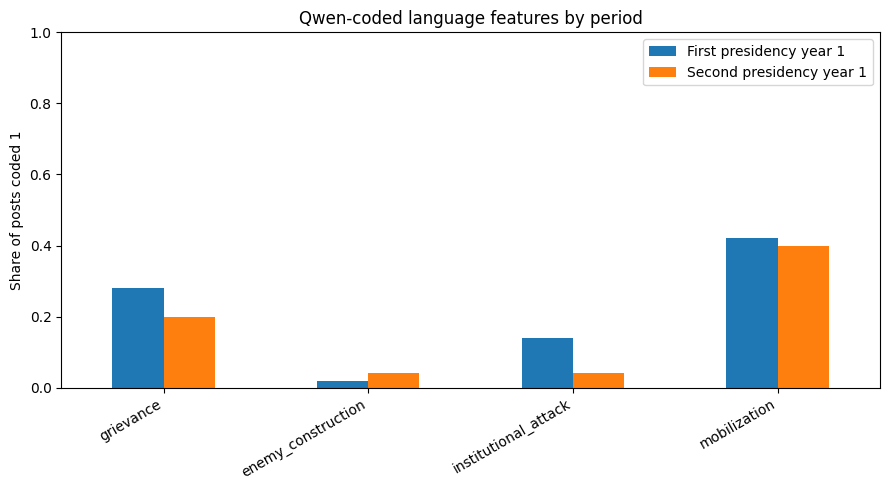

In [52]:
summary_plot = (
    qwen_results
    .groupby("period")[coding_vars]
    .mean()
    .T
)

summary_plot.columns = [
    "First presidency year 1" if col == 1 else "Second presidency year 1"
    for col in summary_plot.columns
]

summary_plot.plot(kind="bar", figsize=(9, 5))

plt.ylabel("Share of posts coded 1")
plt.title("Qwen-coded language features by period")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

So seems like Trump has gotten nicer? Do you get the same results?

## Group exercise: choose your own question

Each group chooses a different concept and repeats the workflow.

Possible research questions:

1. **Policy vs. personality**  
   Did Trump discuss concrete policies more or less in the second period?

2. **Enemies and targets**  
   Which enemies appear most often: media, Democrats, courts, migrants, foreign actors, Republicans?

3. **Mobilization**  
   Are second-period posts more likely to ask supporters to act?

4. **Emotional style**  
   Is the second period more angry, triumphant, fearful, or mocking?

5. **Institutional delegitimation**  
   Are courts, prosecutors, elections, and media attacked more often?

6. **Campaign-style communication**  
   Does presidential communication remain campaign-like?

